# Improving the Phase 2 search: two rounds, and the literature behind them

**Read [`02-structural-encoding.ipynb`](02-structural-encoding.ipynb) first.** It builds the
structural codec, the depth-first search with its product bound, and the controller
that asks (target, window) questions. It ends (§13) with five measured reasons why
Phase 2 did not gain more:

| | the limit | where notebook 02 showed it |
|---|---|---|
| 1 | the question list ends long before the clock: a 32-query cap | §8: 5 ms used of a 1 s budget |
| 2 | target **rectangles** miss trade-offs that only the **product** C × S rules out | §13.2: (12, 8) against (10, 10) |
| 3 | most questions are refused before any search (`INFEASIBLE`) | §8: 24 of 32 queries |
| 4 | windows of four operations moving ±2 cycles are too local | §8.1: `mixed_broadcast` |
| 5 | the proposed "model" was provably a one-bit mutation | §11 |

This notebook explains the two rounds of work that answered them.

- **Round 1, the objective-index protocol** (24 September). Codex read the problem
  against five pieces of published work and proposed a *ladder* of four solvers,
  A1 to A4. Each adds one mechanism to the one below. The round also included a
  genuinely predictive learner to replace the mutation. Claude implemented and
  measured it on a fresh cohort of 200 programs.
- **Round 2, the next round** (25 September). It repaired an accounting defect
  that review found in round 1. It compared round 1's winner with an earlier
  optimiser, and it took the winner apart to find which half of it worked. It also
  asked, with an economic test, whether learning could ever pay for itself inside a
  real query.

Every section follows the same pattern as notebooks 00 to 02. It states the idea and
names the paper it came from. It runs the mechanism live on something small enough
to see, reads the frozen measurement, and then says what the measurement does and
does not show.

**Source of truth.** The solvers live in `research/objective_index_search.py` (round 1,
frozen) and `research/next_round_search.py` (round 2, a versioned successor). The
learner is `research/schema_ranker.py`. The measurements are under
`results/phase2_structural_encoding/objective_index_20260924/` and `.../next_round_20260925/`.
No number in the prose is retyped. Each is printed by the cell above it.

---

## 0. Setup

In [1]:
import collections
import json
import math
import sys
from pathlib import Path

ROOT = Path("/Users/alberto/Documents/projects/CausalBool/luminal-challenge").resolve()
for entry in (str(ROOT / ".reference"), str(ROOT), str(ROOT / "notebooks")):
    if entry not in sys.path:
        sys.path.insert(0, entry)

import machine
import direct_contract as dc
import direct_compiler as dcomp
import direct_optimizer as dopt
import schema_index as si

from research import structural_encoding as se          # the codec (notebook 02)
from research import run_structural_experiments as rse  # the Phase 2 controller, A0
from research import objective_index_search as ois      # round 1: the A1..A4 ladder, frozen
from research import objective_index_common as oic
from research import schema_ranker as sr                # round 1: the schema-tree learner

import viz

EVIDENCE = ROOT / "results/phase2_structural_encoding"
ROUND1 = EVIDENCE / "objective_index_20260924"
ROUND2 = EVIDENCE / "next_round_20260925"
FIXTURES = {f["id"]: f for f in json.loads((ROOT / "plan/phase2/FIXTURES.json").read_text())["fixtures"]}
load = lambda path: json.loads(path.read_text())

def bootstrap(name):
    prog = machine.load_program(ROOT / f".reference/programs/{name}.json")
    prog_facts = dc.derive(prog)
    compiled, _ = dcomp.compile_with_report(prog, dcomp.DEFAULT_LIMITS, optimise=False)
    return prog, prog_facts, se.issue_cycles_of(prog, compiled["bundles"]), dict(compiled["scratch"])

for name, module in (("objective_index_search", ois), ("schema_ranker", sr), ("viz", viz)):
    print(f"{name:24} {Path(module.__file__).relative_to(ROOT)}")
print("round 1 arms:", oic.NEW_ARMS)

objective_index_search   research/objective_index_search.py
schema_ranker            research/schema_ranker.py
viz                      notebooks/viz.py
round 1 arms: ('A1_deadline_control', 'A2_product_search', 'A3_propagated_search', 'A4_multiscale_search')


---

# 1. The ladder, and how a winner was chosen

Round 1 fixed five solvers **before measuring anything**. The protocol calls them
"a fixed solver ladder, not a tunable grid":

| arm | what it adds | answers limit | idea from |
|---|---|---|---|
| **A0** `frozen_phase2` | notebook 02's `structural_bound`, byte for byte | the control | — |
| **A1** `deadline_control` | removes the 32-query cap; keeps asking until the clock stops | 1 | — |
| **A2** `product_search` | replaces the target rectangles with one **strict-product** domain per window | 2, 3 | Castañeda Lozano et al. 2019 |
| **A3** `propagated_search` | adds four **sound propagation** rules, each leaving a checkable reason | cost | Ohrimenko, Stuckey & Codish 2009 |
| **A4** `multiscale_search` | adds **larger, related neighbourhoods** and a **discrepancy-ordered** traversal | 4 | Shaw 1998; Harvey & Ginsberg 1995 |

Each arm is the one above it plus exactly one mechanism, so adjacent arms form an
**ablation**: A2 against A1 measures product domains and nothing else. The one
exception is A4, which adds two things at once. Round 2 exists partly to take them
apart.

The selection rule was fixed in advance as well. Run all five on 100 *development*
programs at three budgets. Pick the arm with the largest mean paired
log(J_A0 / J_arm) at 0.1 s, breaking ties towards cheaper, then towards lower
arm number. Freeze it, with its source hashes, and only then measure it on 200
**fresh** programs it has never seen. The public programs were never used for
selection.

In [2]:
development = load(ROUND1 / "DEVELOPMENT.json")
print("development population:", development["population"])
print("selected arm          :", development["selection"].get("selected", "A4_multiscale_search"),
      f"  effect vs A0 at 0.1 s: {development['selection']['best_effect']:+.4f}")
print("decided at            :", development["decided_utc"])

development population: development seeds 800000-800099 (100 programs), 3 repetitions; public programs never enter selection
selected arm          : A4_multiscale_search   effect vs A0 at 0.1 s: +0.0663
decided at            : 2026-09-25T00:29:12Z


---

# 2. A1: stop stopping early

The simplest change comes first. Notebook 02 §8 stopped after 32 queries with 99% of
its budget unused. A1 removes the cap and changes nothing else: the same targets,
the same windows, the same search.

In [3]:
vr = bootstrap("08_vector_reduction")
runs = {}
for arm in oic.NEW_ARMS:
    t, a, record = ois.optimise(*vr, arm=arm, budget_seconds=0.1)
    runs[arm] = (se.objective(vr[1], t, a), record)

C, S, J = se.objective(vr[1], vr[2], vr[3])
print(f"08_vector_reduction, bootstrap C={C} S={S} J={J}, budget 0.1 s\n")
for arm, ((c, s, j), record) in runs.items():
    statuses = {k: v for k, v in record["statuses"].items() if v}
    print(f"{arm:22} -> C={c} S={s} J={j:4}   {record['seconds'] * 1000:6.1f} ms   "
          f"stopped: {record['stopped_because']:13} {statuses}")

08_vector_reduction, bootstrap C=12 S=40 J=480, budget 0.1 s

A1_deadline_control    -> C=12 S=33 J= 396      7.0 ms   stopped: pass_complete {'SAT': 1, 'UNSAT': 13, 'INFEASIBLE': 47}
A2_product_search      -> C=12 S=33 J= 396      4.8 ms   stopped: pass_complete {'SAT': 1, 'UNSAT': 7, 'NO_STRICT_IMPROVEMENT': 6}
A3_propagated_search   -> C=12 S=33 J= 396      3.5 ms   stopped: pass_complete {'SAT': 1, 'UNSAT': 7, 'NO_STRICT_IMPROVEMENT': 6}
A4_multiscale_search   -> C=12 S=32 J= 384    100.1 ms   stopped: pass_complete {'NO_STRICT_IMPROVEMENT': 15, 'SAT': 2, 'SUPERSEDED': 14, 'UNKNOWN_DEADLINE': 1, 'UNSAT': 15}


A1 asks 61 questions instead of 32 and **still finishes in a few milliseconds**. It
does not run out of time. It runs out of **questions**: `stopped: pass_complete`
means every (target, window) pair was asked and none improved. Removing the cap
helps only on programs where the 33rd question would have been the good one.

Measured on the 200 fresh programs at 0.1 s, A1 against A0 gives +0.0055 in log J
(about 0.5% lower geometric J), with 18 wins, 182 ties and no losses. That is real
and small. It confirms that limit 1 was a symptom. The real problem is that the
list itself is short and poorly shaped.

---

# 3. A2: ask for the product, not a rectangle

**The idea** comes from combinatorial compiler optimisation. Castañeda Lozano,
Carlsson, Hjort Blindell and Schulte (2019) solve instruction scheduling and register
allocation **jointly, under one objective**, with constraint propagation and
branch-and-bound. They trade compile time for output quality. The lesson taken here
is narrow: if the objective is C × S, search on C × S. Do not replace it with two
separate ceilings that only approximate it.

## 3.1 The integer-cap lemma, step by step

Take one window at one incumbent with product J₀. Everything outside the window is
fixed, and that alone gives two lower bounds for **any** completion:

- **L_C**: C is at least the dependency and engine bound, and at least one more than
  the latest *fixed* issue cycle.
- **L_S**: S is at least the widest value, and at least the end of the highest
  *fixed* block.

A strict improvement needs C × S ≤ J₀ − 1. Since S ≥ L_S, that forces
C ≤ (J₀ − 1) / L_S, and since C ≥ L_C, it forces S ≤ (J₀ − 1) / L_C. Both are
integers, so:

  **C_cap = ⌊(J₀ − 1) / L_S⌋,  S_cap = ⌊(J₀ − 1) / L_C⌋**

Every strict improvement in this window lies inside the box
[L_C, C_cap] × [L_S, S_cap]. So the domain can be cut to that box **without losing a
single improvement**. The search then enforces the real condition, C × S < J_best,
at every node. If a cap falls below its lower bound, the window provably contains no
improvement and is reported as `NO_STRICT_IMPROVEMENT`. That is a proof, which the
old `INFEASIBLE` refusal was not.

Here are the numbers for the first window of `vector_reduction`, from the solver's
own `product_caps`:

J0     : 480
C0     : 12
S0     : 40
LC     : 12
LS     : 24
Ccap   : 19
Scap   : 39
status : OK

C_cap = floor((480 - 1) / 24) = 19   (then clipped to the horizon, 43)
S_cap = floor((480 - 1) / 12) = 39
old targets for the same incumbent: [(11, 40), (12, 39), (13, 36), (11, 43)]


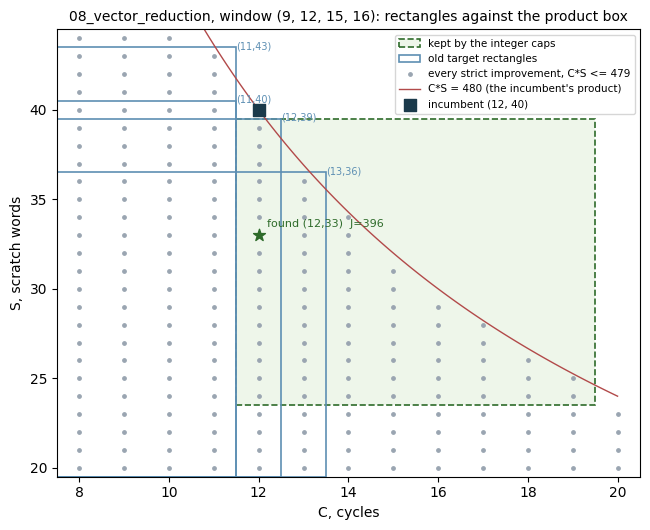

In [4]:
window = (9, 12, 15, 16)
caps = ois.product_caps(vr[1], vr[2], vr[3], window)
for key in ("J0", "C0", "S0", "LC", "LS", "Ccap", "Scap", "status"):
    print(f"{key:7}: {caps[key]}")
print(f"\nC_cap = floor(({caps['J0']} - 1) / {caps['LS']}) = {(caps['J0'] - 1) // caps['LS']}"
      f"   (then clipped to the horizon, {vr[1].horizon})")
print(f"S_cap = floor(({caps['J0']} - 1) / {caps['LC']}) = {(caps['J0'] - 1) // caps['LC']}")
print("old targets for the same incumbent:", dopt.targets_for(vr[1], caps["C0"], caps["S0"]))

viz.show_objective_plane(
    (caps["C0"], caps["S0"]),
    "08_vector_reduction, window (9, 12, 15, 16): rectangles against the product box",
    targets=dopt.targets_for(vr[1], caps["C0"], caps["S0"]),
    points=[("found", (12, 33))], caps=caps, c_range=(8, 20), s_range=(20, 44))

The green dashed box is everything the product domain keeps: cycles 12 to 19 and
scratch 24 to 39. Every grey dot inside it is a potential strict improvement, and
the search is allowed to find any of them. The four rectangles cover only part of
the region. Worse, the (11, 40) and (11, 43) rectangles demand C ≤ 11 when a fixed
operation outside the window already forces C ≥ 12, which is why they were refused
as `INFEASIBLE`.

The lemma was proved in writing and then checked. On 87 domains small enough to
enumerate, at 328 thresholds, the capped search found exactly the 21,853 improving
compilations that an independent enumeration of the uncapped neighbourhood found.
The claim is scoped: complete **within the declared window and horizon**, and nothing
wider.

## 3.2 What it changed, measured

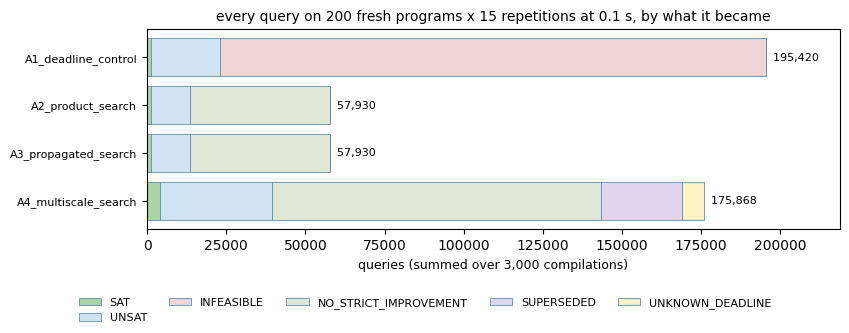

A2 vs A1 at 0.1 s: -0.0011 [-0.0028, 0.0]  W/T/L 0/198/2  compile time x0.82


In [5]:
comparison1 = load(ROUND1 / "COMPARISON.json")
totals = comparison1["query_status_totals"]
order = ["SAT", "UNSAT", "INFEASIBLE", "NO_STRICT_IMPROVEMENT", "SUPERSEDED", "UNKNOWN_DEADLINE"]
arms = [f"{arm}@0.1" for arm in ("A1_deadline_control", "A2_product_search",
                                 "A3_propagated_search", "A4_multiscale_search")]
viz.show_stacked_outcomes(
    [arm.replace("@0.1", "") for arm in arms],
    {name: [totals[arm].get(name, 0) for arm in arms] for name in order},
    "every query on 200 fresh programs x 15 repetitions at 0.1 s, by what it became",
    xlabel="queries (summed over 3,000 compilations)",
    colours={"SAT": viz.CHOSEN, "UNSAT": viz.FILL, "INFEASIBLE": viz.EXCLUDED,
             "NO_STRICT_IMPROVEMENT": "#dfe8d5", "SUPERSEDED": "#e3d5ef",
             "UNKNOWN_DEADLINE": "#fff2c6"})

ladder = {(r["quality"]["candidate"], r["budget"]): r for r in comparison1["ladder_unadjusted_95"]}
step = ladder[("A2_product_search", 0.1)]
print(f"A2 vs A1 at 0.1 s: {step['quality']['point']:+.4f} {[round(x, 4) for x in step['quality']['interval']]}"
      f"  W/T/L {step['quality']['wins']}/{step['quality']['ties']}/{step['quality']['losses']}"
      f"  compile time x{step['compile']['geometric_ratio_candidate_over_control']:.2f}")

The picture changes completely. A1 turns 172,395 questions into `INFEASIBLE`
refusals. A2 asks far fewer questions and **proves** 44,250 of them empty with the
caps. The output does not change: A2 against A1 is −0.0011, with 198 ties and 2
small losses, at 0.82 times the compile time.

**Why no gain?** Because limit 2 was *geometric*. The (12, 8) counterexample shows
that the rectangles have holes. It does not show that real programs have
improvements in those holes, and on this generator they almost never did. A2 still
matters, because it replaced a heuristic refusal with a proof and made each query
cheaper. The ladder is built on it. But the missing gain was not hiding there.

---

# 4. A3: sound propagation, with a reason for every deletion

**The idea** comes from constraint programming. A propagator removes values from a
variable's domain that cannot appear in any solution, *before* the search tries
them. Ohrimenko, Stuckey and Codish (2009), in *Propagation via lazy clause
generation*, make every such removal carry an **explanation**, a small logical
reason that can be checked on its own. Round 1 takes only that discipline. Every
deletion emits a **certificate** with enough local inputs to replay it. Clause
learning itself was deliberately left out, because a state-dependent rank means
something different under a different prefix, so a learned clause could be reused
unsoundly.

The four rules, in the order they are applied until nothing changes:

1. **Precedence.** If v reads u's result with lag ℓ, then t_v ≥ t_u + ℓ. So u cannot
   be later than max(D_v) − ℓ (certificate `PU`), and v cannot be earlier than
   min(D_u) + ℓ (`PL`).
2. **Engine capacity.** If an operation's domain has shrunk to one cycle, it
   *occupies* that cycle. A cycle whose slots are all occupied is removed from every
   other operation on that engine (`EF`). Too many occupants proves the branch
   impossible (`EO`).
3. **Allocation.** Once every time is fixed, two values alive together need disjoint
   blocks. An address with no compatible partner in the other value's domain goes
   (`AL`).
4. **Product bound.** L_C × L_S ≥ J_best prunes the branch (`PB`). It is stronger
   than notebook 02's bound because it also counts widths that are *guaranteed* to be
   alive, whatever the remaining choices.

Here is rules 1 and 2 run live on a product domain of `mixed_broadcast`, the program
Phase 2 could not improve.

op opcode  reads                  writes    lat  incumbent t
 0 vload   -                      weights0    4       0
 1 load    -                      bias0       3       0
 2 load    -                      gate0       3       1
 3 splat   ['bias0']              vbias       1       3
 4 splat   ['gate0']              vgate       1       4
 5 vmul    ['weights0', 'vgate']  scaled      3       5
 6 vadd    ['scaled', 'vbias']    result      1       8
 7 vstore  ['result']             -           1       9

window (0, 2, 3, 4), radius 2, caps C<=17 S<=23
  certificate ('PU', 0, 5, 4, 5, (2,))
  certificate ('PL', 1, 3, 3, 0, (1, 2))
  certificate ('PL', 2, 4, 3, 0, (2,))
  certificate ('PU', 4, 5, 1, 5, (5, 6))
  certificate ('PU', 2, 4, 3, 4, (2, 3))


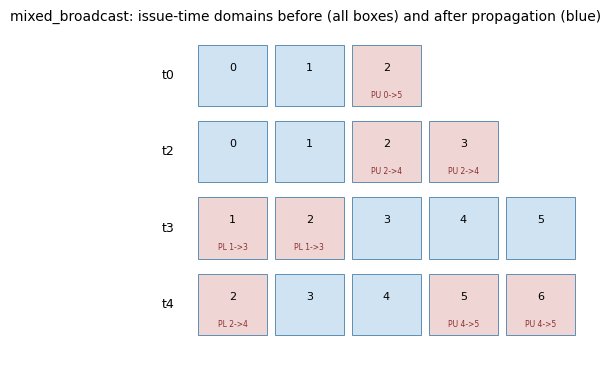

In [6]:
mb = bootstrap("05_mixed_broadcast")
mb_program, mb_facts, mb_times, mb_addresses = mb
print(f"{'op':>2} {'opcode':7} {'reads':22} {'writes':9} lat  incumbent t")
for op in mb_program["operations"]:
    i = op["id"]
    print(f"{i:>2} {op['op']:7} {str(op.get('args') or '-'):22} {op.get('dest') or '-':9} {mb_facts.latency[i]:>3}  {mb_times[i]:>6}")

window = (0, 2, 3, 4)
caps_mb = ois.product_caps(mb_facts, mb_times, mb_addresses, window)
product_domain = se.Domain.from_record(
    ois.product_record("demo", mb_program, mb_facts, mb_times, mb_addresses, window, 2, caps_mb))
stats = ois.PropagationStats(keep=True)
propagator = ois.Propagation(product_domain, stats)
before = {op: tuple(sorted(product_domain.time_domains[op])) for op in product_domain.selected_operations}
after = propagator.times_fixpoint(before)

print(f"\nwindow {window}, radius 2, caps C<={caps_mb['Ccap']} S<={caps_mb['Scap']}")
reasons = collections.defaultdict(dict)
for certificate in stats.certificates:
    print("  certificate", certificate)
    rule = certificate[0]
    if rule in ("PU", "PL"):
        _, u, v, lag, bound, removed = certificate
        target = u if rule == "PU" else v
        for value in removed:
            reasons[target][value] = f"{rule} {u}->{v}"
viz.show_domain_filtering(
    [(f"t{op}", before[op], after[op], reasons[op]) for op in sorted(before)],
    "mixed_broadcast: issue-time domains before (all boxes) and after propagation (blue)")

Read one certificate aloud: `('PL', 1, 3, 3, 0, (1, 2))`. Operation 3 (the splat of
`bias0`) reads operation 1's result, with lag 3. Operation 1 is fixed at cycle 0,
so operation 3 cannot issue before cycle 0 + 3 = 3, and cycles 1 and 2 are removed.
The reason is complete, local and replayable: anyone holding the program can check
it in one line.

The next one is subtler: `('PU', 2, 4, 3, 4, (2, 3))`. It fires only *after*
`('PU', 4, 5, 1, 5, (5, 6))` has cut operation 4's latest cycle to 4. The deletions
feed each other. That is why the rules run to a **fixed point**, and why five
certificates shrink 17 candidate cycles to 9.

Soundness was not assumed. Across the exhaustible test domains, 32,621 propagation
events were checked against 214,545 feasible completions, with **zero** violations.
Two deliberately unsound rules planted in the code were caught.

A second discipline matters as much. Propagation filters the **search's copy** of
each domain and never the codec. A value's rank stays its position in the *unfiltered*
option list, because "the kth surviving value" would silently change what a code means
(notebook 02 §4). Final candidates are round-tripped through the unchanged codec.

## 4.1 What it changed, measured

In [7]:
step = ladder[("A3_propagated_search", 0.1)]
print(f"A3 vs A2 at 0.1 s: quality {step['quality']['point']:+.4f} {step['quality']['interval']}"
      f"  W/T/L {step['quality']['wins']}/{step['quality']['ties']}/{step['quality']['losses']}"
      f"   compile time x{step['compile']['geometric_ratio_candidate_over_control']:.2f}")

A3 vs A2 at 0.1 s: quality +0.0000 [0.0, 0.0]  W/T/L 0/200/0   compile time x0.83


**Exactly zero** change in quality on all 200 programs, at **0.83 times** the compile
time. This is the expected result for a sound propagator. It removes only what the
depth-first search would have rejected anyway, so it can change *when* an answer is
found but never *which* answer. On these small windows, where every query already
finished, it could only make them finish sooner.

Hold on to that 17% saving. Round 2 finds that once the neighbourhoods get large,
propagation becomes the single largest cost of the whole compiler.

---

# 5. A4: bigger, related neighbourhoods, explored by discrepancy

A4 changes two things at once. Both answer limit 4: the questions are too local.

## 5.1 The catalogue: large neighbourhood search

**The idea** is Shaw's *large neighbourhood search* (CP 1998, on vehicle routing):
release a group of **related** decisions, keep the rest of the solution fixed, and
re-solve the group exactly with constraint search. Relatedness is the art. Releasing
random decisions wastes the solver on groups that cannot interact.

A4 builds a **catalogue** of windows from five queues, merged round-robin so that
large windows are not starved behind small ones:

- the old `windows_for` windows, 4 operations, radius 2;
- for k = 4, 8 and 16 (radius 4, 4 and 8): the k **latest-issued** operations (they
  decide C), the k operations around the **memory peak** (they decide S), and
  contiguous blocks of k;
- the **whole program**, over its full horizon, when it has at most 16 operations.

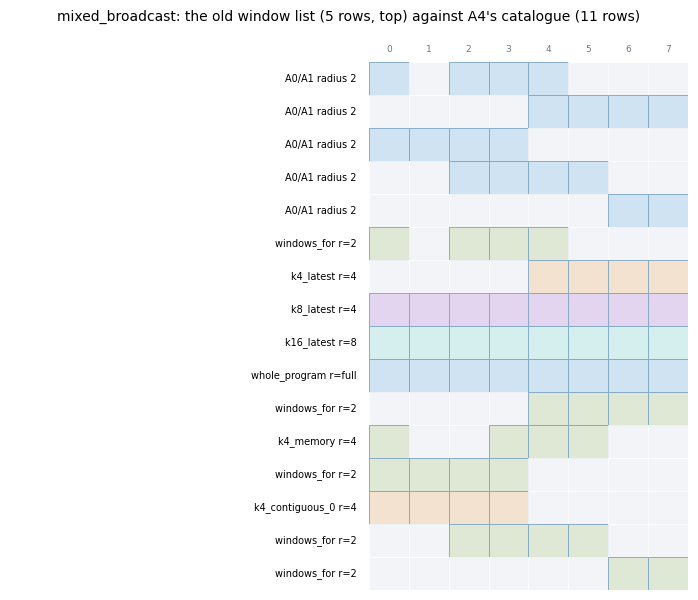

In [8]:
catalogue = ois.build_catalog(mb_facts, mb_times, mb_addresses)
old_windows = dopt.windows_for(mb_facts, mb_times, mb_addresses, scratch_first=True)
entries = [(f"A0/A1 radius 2", w) for w in old_windows]
entries += [(f"{e['policy']} r={e['radius']}", e["window"]) for e in catalogue]
viz.show_window_catalog(entries, mb_facts.count,
    f"mixed_broadcast: the old window list ({len(old_windows)} rows, top) against A4's catalogue ({len(catalogue)} rows)")

The top rows are everything A0 to A3 could ever ask on this program: small windows,
each moving four operations by at most two cycles. Below them, A4's catalogue
releases *all eight* operations (the `k8_latest` row, radius 4), then all eight again
at radius 8, then the whole program over its full horizon.

## 5.2 The traversal: limited discrepancy search

**The idea** is Harvey and Ginsberg's *limited discrepancy search* (IJCAI 1995). If a
good heuristic orders the choices, the best solutions tend to disagree with it in only
a few places. So explore every solution with **zero** disagreements first, then every
one with **one**, then two, instead of spending the whole budget below the first
choice as depth-first search does.

Here the heuristic is already built into the codec: **rank 0 is the incumbent's
choice** (notebook 02 §3). A *discrepancy* is any decision taken at rank > 0. A4 keeps a
heap of partial codes ordered by (discrepancies, product lower bound, −depth, ranks),
capped at 4,096 entries (beyond that the query stops as `UNKNOWN`, never `UNSAT`).
Queries are paused and resumed in 2 ms slices, up to eight at a time, so that one
hard query cannot consume the budget.

The test-only helper `lds_enumerate` runs exactly that heap order to exhaustion on a
fixture. On `many_ready_1` from notebook 02:

status EXHAUSTED, 55 pops, 22 improving leaves collected

 pop  discrepancies  bound  ranks so far
   0              0     21  ()
   1              0     21  (0,)
   2              1     21  (0, 1)
   3              1     21  (0, 1)
   4              1     21  (0, 1, 0)
   5              1     21  (0, 2)
   6              1     21  (0, 2)
   7              1     21  (0, 2, 0)
   8              1     21  (1,)
   9              1     21  (1, 0)
  10              1     21  (1, 0)
  11              1     21  (2,)
  12              1     21  (2, 0)
  13              1     21  (2, 0)
  14              2     21  (0, 1, 0, 1)
  15              2     21  (0, 2, 0, 1)
  16              2     21  (0, 2, 0, 2)
  17              2     21  (1, 0, 1)


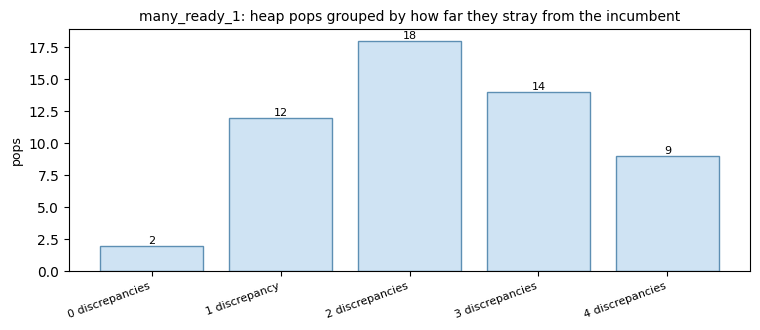

In [9]:
fixture = se.Domain.from_record(FIXTURES["many_ready_1"])
lds = ois.lds_enumerate(fixture, fixture.incumbent, threshold=28)
pops = lds["pop_order"]
print(f"status {lds['status']}, {lds['nodes']} pops, {len(lds['collected'])} improving leaves collected\n")
print(" pop  discrepancies  bound  ranks so far")
for index, (disc, bound, ranks) in enumerate(pops[:18]):
    print(f"{index:>4}  {disc:>13}  {bound:>5}  {ranks}")
by_disc = collections.Counter(disc for disc, _, _ in pops)
viz.show_bars([f"{d} discrepanc{'y' if d == 1 else 'ies'}" for d in sorted(by_disc)],
              [by_disc[d] for d in sorted(by_disc)],
              "many_ready_1: heap pops grouped by how far they stray from the incumbent",
              "pops", fmt="{:.0f}")

The traversal walks outwards from the incumbent. It first takes the path with every
rank 0, then every path that differs in one decision, then two. A depth-first search
walks left to right through the tree in notebook 02 §7. It would examine every
completion under `t4 = 2` before it ever considered changing `t4`.

## 5.3 A4 on the program Phase 2 could not touch

In [10]:
print("bootstrap:", se.objective(mb_facts, mb_times, mb_addresses))
for arm in oic.NEW_ARMS:
    t, a, record = ois.optimise(*mb, arm=arm, budget_seconds=0.1)
    print(f"{arm:22} -> {se.objective(mb_facts, t, a)}  {record['seconds'] * 1000:5.1f} ms  "
          f"stopped: {record['stopped_because']}")
    for step_ in record["improvements"]:
        print(f"      {step_['from_CS']} -> {step_['to_CS']}  via {step_.get('policy', step_.get('kind'))} "
              f"window {step_['window']}")

bootstrap: (10, 24, 240)
A1_deadline_control    -> (10, 24, 240)    3.0 ms  stopped: pass_complete
A2_product_search      -> (10, 24, 240)    1.5 ms  stopped: pass_complete
A3_propagated_search   -> (10, 24, 240)    1.2 ms  stopped: pass_complete


A4_multiscale_search   -> (10, 16, 160)  100.0 ms  stopped: deadline
      [10, 24] -> [10, 17]  via k8_latest window [0, 1, 2, 3, 4, 5, 6, 7]
      [10, 17] -> [10, 16]  via windows_for window [0, 2, 3, 4]


*(A4 runs until its deadline, so on another machine it can find a slightly different
sequence of improvements.)*

A1, A2 and A3 exhaust their question lists within a few milliseconds and change
nothing. A4 finds 10 × 17 through the `k8_latest` window, which releases all eight
operations at radius 4. It then continues from that new incumbent (a new **epoch**,
with a freshly built catalogue) and finds 10 × 16 through an ordinary small window
that had nothing to offer from the old incumbent. The two improvements work together:
the large move opens the way, and a small move finishes it.

## 5.4 What it changed, measured

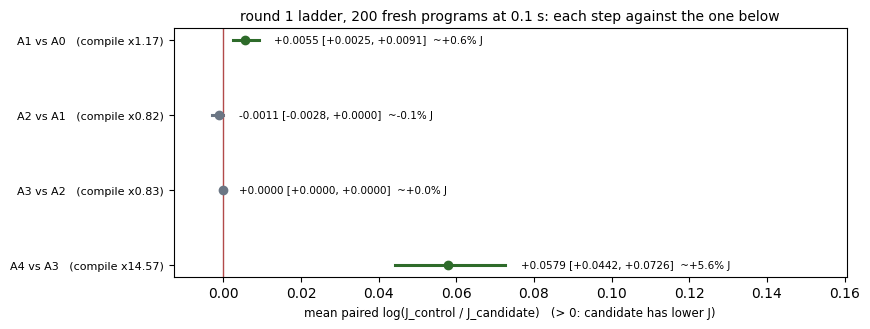

In [11]:
ladder_rows = []
for candidate, control in (("A1_deadline_control", "A0"), ("A2_product_search", "A1"),
                           ("A3_propagated_search", "A2"), ("A4_multiscale_search", "A3")):
    step = ladder[(candidate, 0.1)]
    q = step["quality"]
    ladder_rows.append((f"{candidate.split('_')[0]} vs {control}   (compile x{step['compile']['geometric_ratio_candidate_over_control']:.2f})",
                        q["point"], *q["interval"]))
viz.show_effects(ladder_rows, "round 1 ladder, 200 fresh programs at 0.1 s: each step against the one below")

The whole ladder in one figure. A1 adds a little, A2 and A3 add nothing to quality,
and **A4 adds +0.0579** (about 5.6% lower geometric J), with 93 wins, 107 ties and no
losses. It does this at **14.6 times** A3's compile time. The whole of round 1's gain is
the last step. Because that step bundles two mechanisms, the design cannot say which
one earned it. Round 2 answers that.

---

# 6. The learner: a schema tree instead of a mutation

Notebook 02 §11 proved that "freeing a coordinate of the elite cover" is exactly
one-bit mutation, so it can learn nothing. Round 1 replaced it with a model that
*predicts*.

**The idea** comes from Gasse, Chételat, Ferroni, Charlin and Lodi (NeurIPS 2019). A
learned model can **guide** an exact search, deciding what to try first, without ever
being trusted to decide feasibility. Their model is a graph neural network, and nothing
of its performance is transferred here. Round 1 keeps the principle and uses the
smallest model that fits the representation: a **depth-3 decision tree over the code's
own bits**, grown with the Gini criterion of Breiman, Friedman, Olshen and Stone
(1984). No hyperparameter is searched.

The tree is itself an index-set object. Each leaf fixes the bits it was split on and
leaves the others free, so **every leaf is a cube**. The leaves partition the whole
code universe, and each carries a smoothed score, (positives + 1) / (count + 2).
Here is one, fitted live on the training half of a frozen evaluation fixture.

10-bit codes, 72 legal compilations: 36 train / 18 validation / 18 test
label: J <= 20 (the top 10% of training)  ->  6 positives of 36

split at depth 0 on bit x4 of x0..x9:**********
split at depth 1 on bit x3 of x0..x9:****0*****
split at depth 2 on bit x7 of x0..x9:***00*****

leaf x0..x9:***00**0**   4/4 good in training   score 0.833
leaf x0..x9:***00**1**   2/4 good in training   score 0.500
leaf x0..x9:***10*****   0/13 good in training   score 0.067
leaf x0..x9:****1*****   0/15 good in training   score 0.059


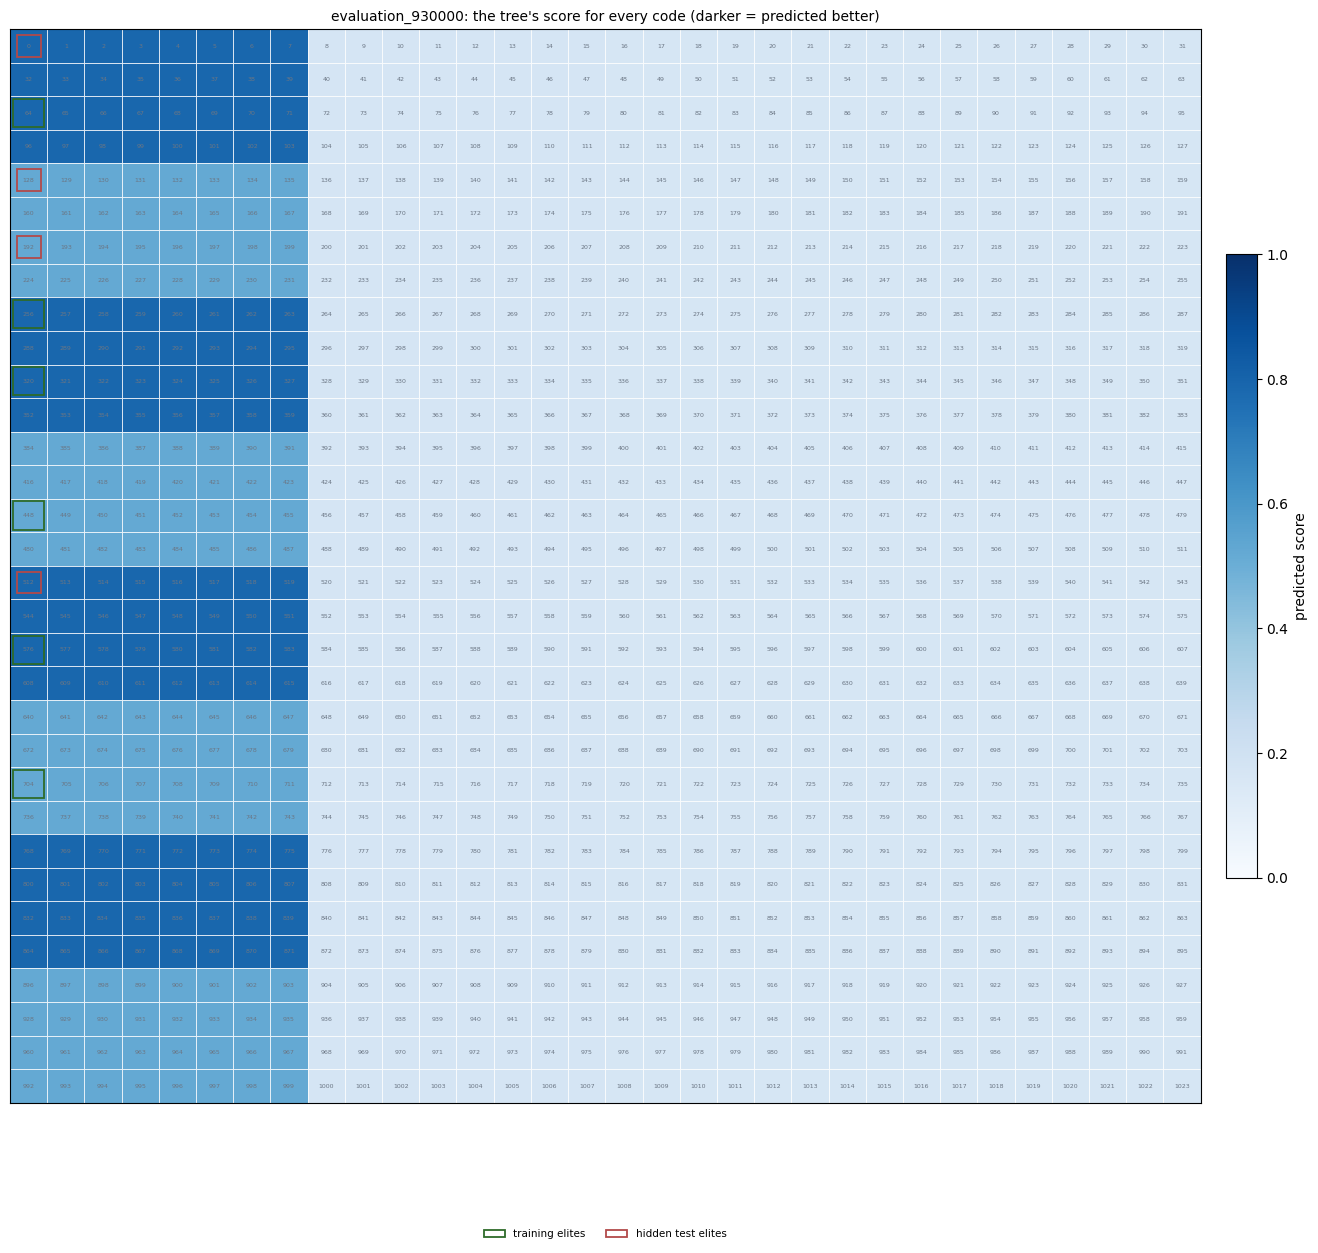

In [12]:
fixture_dir = ROUND1 / "fixtures/evaluation/evaluation_930000"
oracle = load(fixture_dir / "oracle.json")
split = load(fixture_dir / "split.json")
by_identity = {x["identity"]: x for x in oracle["feasible"]}
train = [by_identity[i] for i in split["train"]]
test = [by_identity[i] for i in split["test"]]
bits = oracle["bits"]

train_codes = [int(x["structural_rank_index"]) for x in train]
threshold, labels = sr.labels([x["product"] for x in train])
tree = sr.fit_tree(bits, train_codes, labels)

print(f"{bits}-bit codes, {len(oracle['feasible'])} legal compilations: "
      f"{len(train)} train / {len(split['validation'])} validation / {len(test)} test")
print(f"label: J <= {threshold} (the top 10% of training)  ->  {sum(labels)} positives of {len(labels)}\n")
for split_ in tree.splits:
    print(f"split at depth {split_['depth']} on bit x{split_['coordinate']} of {split_['schema']}")
print()
for leaf in tree.leaves:
    print(f"leaf {leaf.cube.label()}   {leaf.positive}/{leaf.count} good in training   score {float(leaf.score):.3f}")

elite_train = [z for z, label in zip(train_codes, labels) if label]
test_elite = [int(x["structural_rank_index"]) for x in test if x["product"] <= threshold]
viz.show_index_scores(bits, {z: float(tree.predict(z)) for z in range(1 << bits)},
                      "evaluation_930000: the tree's score for every code (darker = predicted better)",
                      outlined={"training elites": elite_train, "hidden test elites": test_elite})

The first split, on bit x4, separates the region where every good training compilation
lives from one with none. The tree has found a **schema**: *"x3 = x4 = 0, and x7 = 0 if
possible"*. It is a statement about which ranks good compilations take, written as
cubes, which is the H3 idea of notebook 02 used as a predictor rather than a
description. The dark cells are where it would search first, and the red outlines
are the hidden test elites.

## 6.1 The fair comparison

A ranker is only worth something if it orders **the same candidates** better than
cheap alternatives. The protocol therefore builds one common **pool** per fixture:
Hamming-distance-1 and then distance-2 neighbours of the training elites, plus
uniform random codes. It then orders that pool in several ways: by tree score, by
Hamming distance to the elites, at random, and by a tree fitted on **shuffled labels**.
Here are the first 32 proposals of three orderings on this fixture.

In [13]:
pool = sr.candidate_pool(bits, train_codes, elite_train, sr.arm_seeds(oracle["domain_sha256"])["pool"])
legal = {int(x["structural_rank_index"]): x["product"] for x in oracle["feasible"]}
test_codes = {int(x["structural_rank_index"]) for x in test}
print(f"pool: {pool['size']} codes ({pool['hamming']} Hamming neighbours + {pool['random']} random)\n")
print(f"{'ordering':10} {'legal':>6} {'good (J<=' + str(threshold) + ')':>12} {'unseen test elites':>19}   (in the first 32)")
for arm in ("tree", "hamming", "ascending"):
    first = sr.order_pool(pool["pool"], arm, elite=elite_train, tree=tree)[:32]
    print(f"{arm:10} {sum(z in legal for z in first):>6} {sum(legal.get(z, 10**9) <= threshold for z in first):>12} "
          f"{sum(z in test_codes and legal[z] <= threshold for z in first):>19}")

pool: 422 codes (166 Hamming neighbours + 256 random)

ordering    legal good (J<=20)  unseen test elites   (in the first 32)
tree            5            1                   1
hamming        11            5                   3
ascending       7            1                   1


On this fixture the tree finds one unseen good compilation in its first 32 proposals,
and **plain Hamming order finds three**. That is not bad luck on one fixture. It is
the round-2 result in miniature (§9.5).

## 6.2 Why round 1 could not measure learning at all

The confirmatory endpoint was *the best test-set J found by the deadline, or the
training minimum if nothing better was found*. Look at this fixture's numbers:

In [14]:
print("training minimum J:", min(x["product"] for x in train))
print("test minimum J    :", min(x["product"] for x in test))
print("every legal J     :", sorted({x["product"] for x in oracle["feasible"]}))
learning = load(ROUND1 / "LEARNING.json")
print("\nacross all evaluation fixtures:", learning["design_diagnostic"])
print("H_LEARN:", {k: v["verdict"] for k, v in learning["H_LEARN"]["contrasts"].items()})

training minimum J: 20
test minimum J    : 20
every legal J     : [20, 24, 28]

across all evaluation fixtures: {'consequence': 'best_test_J equals min_training_J for every arm on every fixture with no such object; if the count is 0 every H_LEARN contrast is identically 0 and H_LEARN cannot pass', 'evaluation_fixtures_with_a_test_object_below_training_minimum': 0, 'of': 30}
H_LEARN: {'hamming': 'INCONCLUSIVE', 'random': 'INCONCLUSIVE', 'shuffled_tree': 'INCONCLUSIVE'}


The best compilation was already in the training half. No arm could beat the training
minimum, because nothing better existed, so every contrast was exactly zero on **all 30**
fixtures. The frozen oracle and split proved this *before* evaluation, and the release
reported it as a design failure rather than a finding about learning. H_LEARN therefore
**failed by construction**, and the end-to-end learned compiler, implemented and frozen
in advance, was correctly never run.

---

# 7. Round 1 in one table

The confirmatory comparison used 200 fresh programs (40 per family) with 15
repetitions each, at 0.1 s. Three controls were tested with Bonferroni-adjusted 98.33%
intervals.

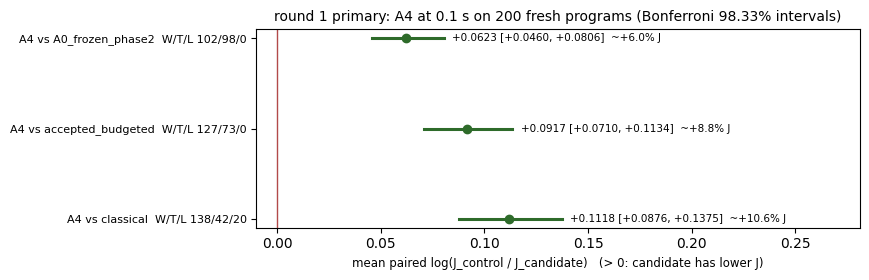

claim: best average output quality among A0, accepted_budgeted and classical at 0.1 s on this fresh population
compile time, A4 / A0_frozen_phase2  : x11.65
compile time, A4 / classical         : x76.20
compile time, A4 / accepted_budgeted : x0.82

public score A4_multiscale_search@0.1   2.088945
public score A0_frozen_phase2@0.1       2.032760
public score accepted_budgeted@0.1      2.008466
public score classical@None             1.901379


In [15]:
primary = comparison1["primary"]
rows = []
for control, c in primary["contrasts"].items():
    rows.append((f"A4 vs {control}  W/T/L {c['wins']}/{c['ties']}/{c['losses']}", c["point"], *c["interval"]))
viz.show_effects(rows, "round 1 primary: A4 at 0.1 s on 200 fresh programs (Bonferroni 98.33% intervals)")
print("claim:", primary["claim_text"])
runtime = comparison1["runtime_primary_bonferroni"]
for key in ("A0_frozen_phase2:compile_seconds", "classical:compile_seconds", "accepted_budgeted:compile_seconds"):
    print(f"compile time, A4 / {key.split(':')[0]:18}: x{runtime[key]['geometric_ratio_candidate_over_control']:.2f}")

public = load(ROUND1 / "PUBLIC_SCORE.json")["score"]["scores"]["arms"]
print()
for arm in ("A4_multiscale_search@0.1", "A0_frozen_phase2@0.1", "accepted_budgeted@0.1", "classical"):
    key = next(k for k in public if k.startswith(arm))
    print(f"public score {key:26} {public[key]['min']:.6f}")

All three lower bounds are above zero. The protocol's own wording therefore applies:
A4 has **the best average output quality among these three controls at 0.1 s on this
population**. That means about 6.0% lower geometric J than Phase 2, 8.8% lower than the
accepted optimiser and 10.6% lower than classical. It is **not** best everywhere: it loses
to classical on 20 of 200 programs. It costs **11.65 times** Phase 2's compile time and
76 times classical's, so it is a quality-for-time trade, not a dominance. On the public
suite it scores 2.0889, against 2.0328 for Phase 2.

---

# 8. Round 2: why another round

Codex's review of round 1 accepted the measurements but found one defect. It also found
three questions the round could not answer.

1. **A defect.** In A4 without a learner, candidates whose validation was cut off by the
   deadline were not counted, because the counter sat inside the learner's branch.
   Decisions were not affected, since a late candidate was still rejected, but the
   report said "0 interrupted" when the truth was "some".
2. **Which optimiser is better?** An earlier campaign had produced another candidate,
   `cap512_wider`: Phase 2's controller with a 512-query cap and wider windows. It
   scored *higher* on the public suite (2.1027 against 2.0889). The two had been measured
   on different cohorts.
3. **Catalogue or traversal?** A4 bundled both.
4. **Can learning ever pay?** Round 1 could not tell.

Round 2 was planned so that *no positive result was required*. It stated that closing
an unproductive direction counts as a successful outcome.

## 8.1 The repair

The fix lives in a **versioned successor**, `research/next_round_search.py`. It is a
copy of the frozen owner that records the frozen file's hash and lists its changes, so
the historical measurements still describe their own source. On the reviewer's probe
the frozen owner returns 0 interrupted validations and the successor returns 1. With a
deterministic clock, the two make **identical decisions** node for node: the same
traces, incumbents, statuses and certificate streams. The repair changes the report
and nothing else.

## 8.2 Which optimiser

In [16]:
comparison2 = load(ROUND2 / "COMPARISON.json")
p = comparison2["primary"]
print(f"primary: {p['endpoint']}")
print(f"   estimate {p['estimate']:+.4f}  95% {[round(x, 4) for x in p['interval_95']]}"
      f"   compile-time ratio A4/earlier {p['compile_ratio_A4_over_earlier_geometric']:.3f}")
print("   by family:", {k: round(v["mean"], 4) for k, v in p["family_breakdown"].items()})

public2 = load(ROUND2 / "PUBLIC_SCORE.json")["scores"]["arms"]
print()
for key in ("earlier_cap512_wider@0.1", "cell_a4cat_heap@0.1", "cell_a4cat_dfs@0.1", "classical@None"):
    print(f"public score {key:26} {public2[key]['max']:.6f}")

primary: mean paired log(J_earlier / J_A4) at 0.1 s
   estimate +0.0312  95% [0.0182, 0.046]   compile-time ratio A4/earlier 0.978
   by family: {'aliasing': 0.0534, 'dependency': 0.0376, 'mixed': 0.0391, 'scalar': 0.0114, 'vector': 0.0148}

public score earlier_cap512_wider@0.1   2.102747
public score cell_a4cat_heap@0.1        2.088945
public score cell_a4cat_dfs@0.1         2.187957
public score classical@None             1.901379


On 200 fresh programs, repaired A4 beats the earlier optimiser by +0.0312 (about 3.1%
lower geometric J, 95% interval [0.018, 0.046]) at the same cost. It wins in every
family. On the eight public programs the order **reverses**: 2.1027 for the earlier
optimiser against 2.0889. Both results are exact and neither overrides the other. They
answer different questions: one is about a generator population, the other about eight
fixed programs. This is the clearest warning in the whole project against reading the
public score as a population estimate.

(`cell_a4cat_heap` is repaired A4 under round 2's naming: A4's catalogue with the
heap traversal.)

## 8.3 Catalogue or traversal: a 2 × 2 factorial

Cross the two components: catalogue ∈ {A3's small windows, A4's multiscale catalogue}
× traversal ∈ {depth-first, discrepancy heap}. Run all four cells on 100 development
programs, and read off the main effects and the interaction.

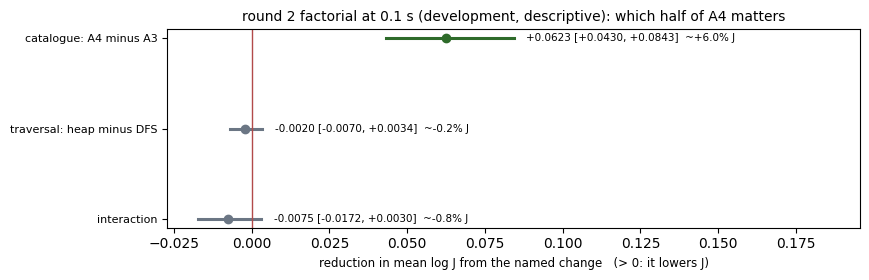

cell means (log J): {'cell_a3cat_dfs': 5.7752, 'cell_a3cat_heap': 5.7735, 'cell_a4cat_dfs': 5.7091, 'cell_a4cat_heap': 5.7149}


In [17]:
factorial = load(ROUND2 / "FACTORIAL.json")["budgets"]["0.1"]["factorial"]
names = [("catalog_effect_a4_minus_a3", "catalogue: A4 minus A3"),
         ("traversal_effect_heap_minus_dfs", "traversal: heap minus DFS"),
         ("interaction", "interaction")]
rows = []
for key, label in names:
    c = factorial[key]
    # The factorial reports log J differences (negative = lower J). Flip the sign so that,
    # as in every other figure, positive means the named change lowers J.
    rows.append((label, -c["estimate"], -c["interval_95"][1], -c["interval_95"][0]))
viz.show_effects(rows, "round 2 factorial at 0.1 s (development, descriptive): which half of A4 matters",
                 xlabel="reduction in mean log J from the named change   (> 0: it lowers J)")
print("cell means (log J):", {k: round(v, 4) for k, v in factorial["cell_family_mean_log_J"].items()})

**The catalogue is everything.** Switching to A4's catalogue lowers log J by 0.062.
Switching the traversal from depth-first to the discrepancy heap does nothing
measurable. If anything, J rises slightly (0.002 in log J, with an interval spanning
zero), and the interaction is also indistinguishable from zero. Shaw's idea earned the gain. Harvey and
Ginsberg's idea, *on these problems and with this incumbent-first heuristic*, did not.
Once the right windows are asked, depth-first search inside them does just as well.

The development rule then selected `cell_a4cat_dfs`, the multiscale catalogue with plain
depth-first traversal, as the round-2 candidate. On the confirmation cohort it is
descriptively the best cell. But it missed both pre-registered routes to a "better"
claim: at least 2% lower J than A4, or at least 10% cheaper at no loss. Its J ratio
against A4 is 0.989, with an upper bound of 0.9997 against a target of 0.98. The verdict
is **TARGET_NOT_REACHED**.

## 8.4 Where the time goes

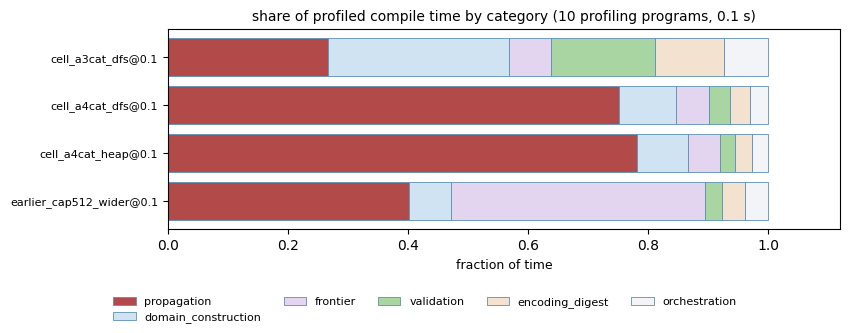

worklist propagation variant: compile time -4.8%  (gate: 10%)  -> reached: False


In [18]:
bottlenecks = load(ROUND2 / "BOTTLENECKS.json")
categories = ["propagation", "domain_construction", "frontier", "validation", "encoding_digest", "orchestration"]
cells = ["cell_a3cat_dfs@0.1", "cell_a4cat_dfs@0.1", "cell_a4cat_heap@0.1", "earlier_cap512_wider@0.1"]
viz.show_stacked_outcomes(
    cells, {c: [bottlenecks[cell]["shares"][c] for cell in cells] for c in categories},
    "share of profiled compile time by category (10 profiling programs, 0.1 s)",
    xlabel="fraction of time", totals=False,
    colours={"propagation": "#b24a4a", "domain_construction": viz.FILL, "frontier": "#e3d5ef",
             "validation": viz.CHOSEN, "encoding_digest": "#f3e2cf", "orchestration": viz.EMPTY})
engineering = load(ROUND2 / "ENGINEERING_DECISION.json")["decision_by_budget"]["0.1"]
print(f"worklist propagation variant: compile time -{engineering['compile_time_reduction'] * 100:.1f}%"
      f"  (gate: 10%)  -> reached: {engineering['reduction_at_least_10pct']}")

With the small catalogue, propagation is a quarter of the time. With the multiscale
catalogue it is **three-quarters**. Large neighbourhoods mean long domains, many
precedence edges and many fixpoint passes. The round allowed one engineering attempt:
a worklist fixpoint that re-examines only the constraints touching a changed domain.
It saved 4.8%, short of the 10% gate, so the parent stayed frozen. The prediction had
been 15 to 25%, and the miss is recorded.

## 8.5 Can learning pay? Two gates, both closed

The learning question was split in two, and each part was given its own gate.

- **Mechanism.** On fixtures redesigned so that the test half *does* contain better
  compilations (fixing round 1's design fault), does the tree order a common pool
  better than simple controls?
- **Economics.** Inside a real compilation, does a query ever collect the 20
  case-validated observations the learner needs before it can be fitted?

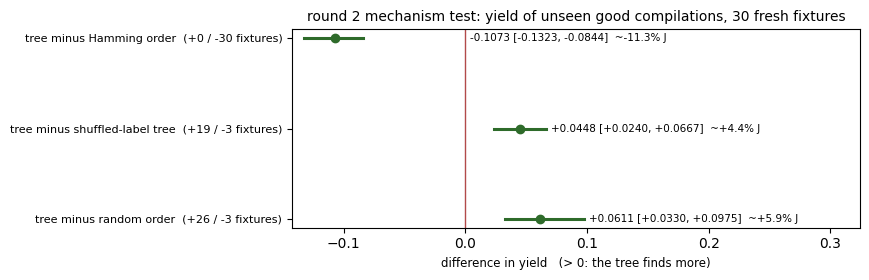

mechanism verdict: FAIL_OR_INCONCLUSIVE
economics: 0 of 100 programs had a query reach 20 validated observations; 33 of 1639 learner queries reached the decision point -> ECONOMICALLY_UNAVAILABLE


In [19]:
feasibility = load(ROUND2 / "LEARNING_FEASIBILITY.json")
contrasts = feasibility["contrasts"]
rows = []
for key, label in (("tree_minus_hamming", "tree minus Hamming order"),
                   ("tree_minus_shuffled_tree", "tree minus shuffled-label tree"),
                   ("tree_minus_random_mean", "tree minus random order")):
    c = contrasts[key]
    rows.append((f"{label}  (+{c['positive']} / -{c['negative']} fixtures)", c["estimate"], *c["interval_98_333"]))
viz.show_effects(rows, "round 2 mechanism test: yield of unseen good compilations, 30 fresh fixtures",
                 xlabel="difference in yield   (> 0: the tree finds more)")
economics = feasibility["economics"]
print("mechanism verdict:", contrasts["mechanism_signal"])
print(f"economics: {economics['programs_with_a_query_reaching_20_validated']} of {economics['programs']} programs "
      f"had a query reach 20 validated observations; {economics['queries_reaching_boundary']} of "
      f"{economics['queries_with_learner']} learner queries reached the decision point -> {economics['verdict']}")

**Mechanism: fail.** The tree beats random order and shuffled labels, so it has
learned *something*. But it **loses to plain Hamming order on all 30 fixtures**. Its
point estimate against shuffled labels (0.045) is also below the 0.05 minimum the
protocol required. Knowing that good compilations sit near good compilations is worth
more than anything the tree adds to it.

**Economics: unavailable.** In 100 real compilations, not one query collected 20
validated observations. Queries are short, most end by proof or improvement within
milliseconds, and the few that reach the learner's decision point have seen at most
one distinct compilation. There is nothing to learn from inside a query.

Per the plan, the non-model compiler is retained, and no learned-compiler campaign is
proposed.

---

# 9. Why we still did not get a much better compiler

Put the three notebooks side by side, and the story is consistent.

1. **The encoding made questions cheap** (notebook 02). Cheap questions exposed the
   real bottleneck: the questions themselves.
2. **Asking more of the same questions barely helps.** A1 gave +0.5%, and product
   domains and propagation gave nothing to quality. They made the same answers cheaper
   and more rigorous.
3. **Asking bigger, related questions helps.** The multiscale catalogue gave about 6%
   over Phase 2. It is the only mechanism with a real effect, and round 2 confirmed that
   it is the catalogue, not the traversal.
4. **Bigger questions cost time**, most of it propagation over long domains: 11.65 times
   Phase 2's compile time, and 76 times classical's. One engineering attempt removed 5%
   of that.
5. **Learning has no material.** Across a whole population, good compilations are
   near good compilations, which Hamming order already exploits. Within a single query
   there are too few observations to fit anything.
6. **The public suite and the population disagree** about which optimiser is best, so
   neither ranking can be quoted without the other.

The honest summary is that the method now finds about 6% lower J than Phase 2 and about
10% lower than the classical greedy compiler, on programs from this generator, at a
large cost in compile time. The remaining gap to a clearly better compiler lies in
**cheaper search inside large neighbourhoods**. It does not lie in a new representation
or in learning. That is where the next round of work would have to start.

---

# 10. Exercises

1. In §2, run A1 on `03_vector_axpy`. How many questions does it ask, and why does it
   stop?
2. In §3.1, compute the caps for window `(13, 14, 17, 18)` by hand, then check them with
   `ois.product_caps`. Is the window worth searching?
3. In §4, change the window to `(0, 1, 2, 3, 4, 5, 6, 7)` with radius 4 and rerun the
   propagation cell. Which rule fires first, and how many values does the fixed point
   remove?
4. In §5.2, count how many pops `lds_enumerate` needs before the first improving leaf.
   Compare it with notebook 02 §7's depth-first node count.
5. In §6, refit the tree with `sr.shuffled_labels(labels, seed=1)` and redraw the score
   map. Where do the dark cells go?

---

## References

The five primary sources behind round 1 were selected by Codex (`plan/PHASE2_SCIENTIFIC_RESEARCH.md`,
consulted 2026-09-24), with the two methodological sources added by the implementation
(`objective_index_20260924/RESEARCH_BASIS.md`). The reported gains of each belong to its
own problems and machines. None establishes a gain for this compiler, and no novelty is
claimed for the combination.

| used in | reference | what was taken, and what was not |
|---|---|---|
| A2, A3 | R. Castañeda Lozano, M. Carlsson, G. Hjort Blindell and C. Schulte, *Combinatorial Register Allocation and Instruction Scheduling*, ACM TOPLAS 41(3), 2019. [arXiv:1804.02452](https://arxiv.org/abs/1804.02452) | Joint decisions under one objective, sound filtering and bound-based pruning. Neither Unison nor its models are imported. |
| A3 | O. Ohrimenko, P. J. Stuckey and M. Codish, *Propagation via Lazy Clause Generation*, Constraints 14(3), 2009. [Monash record](https://research.monash.edu/en/publications/propagation-via-lazy-clause-generation/) | Every deletion carries a local, replayable reason. Clause learning was deliberately not adopted, because rank codes are state-dependent. |
| A4 catalogue | P. Shaw, *Using Constraint Programming and Local Search Methods to Solve Vehicle Routing Problems*, CP 1998, LNCS 1520, pp. 417–431. [Springer](https://link.springer.com/chapter/10.1007/3-540-49481-2_30) | Release a group of related decisions and re-solve it exactly. Round 2 shows that this is the component that works here. |
| A4 traversal | W. D. Harvey and M. L. Ginsberg, *Limited Discrepancy Search*, IJCAI 1995, pp. 607–613. [PDF](https://www.ijcai.org/Proceedings/95-1/Papers/080.pdf) | Prefer few deviations from the preferred choice. This is a best-first heap with a finite frontier, an adaptation rather than their iterative algorithm, and round 2 measured no effect from it. |
| schema ranker | M. Gasse, D. Chételat, N. Ferroni, L. Charlin and A. Lodi, *Exact Combinatorial Optimization with Graph Convolutional Neural Networks*, NeurIPS 2019. [paper](https://proceedings.neurips.cc/paper/2019/hash/d14c2267d848abeb81fd590f371d39bd-Abstract.html) | A learned model orders candidates, and the exact machinery decides. A depth-3 schema tree is used, not a GNN. |
| schema ranker | L. Breiman, J. H. Friedman, R. A. Olshen and C. J. Stone, *Classification and Regression Trees*, Wadsworth, 1984. | The Gini split criterion. Depth, minimum child size and smoothing were fixed by the protocol. |
| statistics | B. Efron and R. J. Tibshirani, *An Introduction to the Bootstrap*, Chapman & Hall, 1993. | Programs resampled within family, with Bonferroni-adjusted percentile intervals where the protocol requires them. |